# Melhoria 3 — Transfer Learning (MobileNetV2)

Esta é a melhoria de **arquitetura**: em vez de treinar uma CNN do zero, reaproveitamos a **MobileNetV2**, uma rede já treinada em 1,4 milhão de imagens (ImageNet). Suas camadas iniciais já sabem extrair bordas, texturas e formas — conhecimento universal que serve para qualquer imagem.

## A estratégia (feature extraction)
- **Base congelada:** mantemos os pesos pré-treinados da MobileNetV2 intactos (não serão alterados no treino). Ela vira um extrator fixo de características.
- **Cabeça nova:** adicionamos uma camada final nossa, com 4 saídas, que é a **única** parte treinada — e quem a ensina é a nossa base de raios-X.

## O que muda em relação ao notebook 04
Reaproveitamos o pipeline do `04` (divisão estratificada + balanceamento), com duas mudanças exigidas pela MobileNetV2:
1. **Tamanho 224×224** (a entrada que ela espera), em vez de 300×300.
2. **`preprocess_input`** (coloca os pixels na faixa −1 a +1 que ela espera), em vez de qualquer normalização 0–1.

O balanceamento (`class_weight`) e a divisão estratificada continuam iguais.

## 1. Importação das bibliotecas

Além das bibliotecas usuais, importamos a `MobileNetV2`, sua função de preprocessamento `preprocess_input`, e as ferramentas de divisão estratificada e pesos de classe (iguais ao notebook 04).

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pathlib

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow versão:", tf.__version__)

TensorFlow versão: 2.21.0


## 2. Listagem dos arquivos e divisão estratificada

Igual ao notebook 04: listamos todas as imagens com seus rótulos e dividimos 80/20 de forma estratificada (proporção exata por classe), com `random_state=42` para reprodutibilidade.

In [7]:
diretorio = pathlib.Path("dataset_unificado")
nomes_classes = sorted([p.name for p in diretorio.iterdir() if p.is_dir()])
print("Classes:", nomes_classes)

caminhos, rotulos = [], []
for indice, classe in enumerate(nomes_classes):
    for arquivo in (diretorio / classe).glob("*"):
        caminhos.append(str(arquivo))
        rotulos.append(indice)

caminhos_treino, caminhos_teste, rotulos_treino, rotulos_teste = train_test_split(
    caminhos, rotulos, test_size=0.2, stratify=rotulos, random_state=42
)
rotulos_treino = np.array(rotulos_treino)

print("Treino:", len(caminhos_treino), "| Teste:", len(caminhos_teste))

Classes: ['COVID-19', 'Normal', 'Pneumonia', 'Tuberculosis']
Treino: 15024 | Teste: 3757


## 3. Construção dos datasets (224×224 + preprocess_input)

Aqui estão as duas mudanças do transfer learning:
- Redimensionamos para **224×224** (tamanho que a MobileNetV2 espera).
- Aplicamos **`preprocess_input`**, que converte os pixels de 0–255 para a faixa **−1 a +1**. Isso é essencial: os filtros congelados da MobileNetV2 só funcionam corretamente se receberem os números nessa faixa.

Não usamos `Rescaling(1./255)` aqui — o `preprocess_input` faz o papel da normalização, do jeito certo para esta rede.

In [8]:
TAMANHO_IMAGEM = (224, 224)
TAMANHO_LOTE = 32

def carregar_imagem(caminho, rotulo):
    img = tf.io.read_file(caminho)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, TAMANHO_IMAGEM)
    img = preprocess_input(img)          # pixels -> faixa -1 a +1
    return img, rotulo

dataset_treino = tf.data.Dataset.from_tensor_slices((caminhos_treino, list(rotulos_treino)))
dataset_treino = dataset_treino.shuffle(buffer_size=len(caminhos_treino), seed=42)
dataset_treino = dataset_treino.map(carregar_imagem).batch(TAMANHO_LOTE).prefetch(tf.data.AUTOTUNE)

dataset_teste = tf.data.Dataset.from_tensor_slices((caminhos_teste, list(rotulos_teste)))
dataset_teste = dataset_teste.map(carregar_imagem).batch(TAMANHO_LOTE).prefetch(tf.data.AUTOTUNE)

for imagens, rot in dataset_treino.take(1):
    print("Formato do lote:", imagens.shape)
    print("Faixa dos pixels: de", float(tf.reduce_min(imagens)), "a", float(tf.reduce_max(imagens)))

Formato do lote: (32, 224, 224, 3)
Faixa dos pixels: de -1.0 a 1.0


## 4. Pesos das classes (balanceamento)

Igual ao notebook 04: recalculamos os pesos com `compute_class_weight("balanced")` sobre o treino estratificado, para compensar o desbalanceamento (sobretudo a Tuberculosis).

In [9]:
pesos_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(rotulos_treino),
    y=rotulos_treino
)
pesos_classes = {i: peso for i, peso in enumerate(pesos_array)}

for i, peso in pesos_classes.items():
    print(f"  {nomes_classes[i]}: peso = {peso:.4f}")

  COVID-19: peso = 1.2983
  Normal: peso = 0.4607
  Pneumonia: peso = 1.0989
  Tuberculosis: peso = 6.7071


## 5. Montando o modelo: base congelada + cabeça nova

- **MobileNetV2** com `include_top=False` (sem a cabeça de 1000 classes do ImageNet) e `trainable = False` (congelada — pesos não serão alterados).
- **GlobalAveragePooling2D:** resume o mapa 7×7×1280 em 1280 números (a média de cada canal), em vez de "esticar" com Flatten.
- **Dropout(0.2):** regularização.
- **Dense(4, softmax):** a cabeça nova — a única parte treinável, que aprende a ligar os 1280 padrões às 4 classes.

No `summary()`, repare que os parâmetros treináveis são apenas ~5 mil (a cabeça), contra ~2,2 milhões congelados (a base).

In [10]:
base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base.trainable = False   # CONGELA a base

modelo = keras.Sequential([
    keras.layers.Input(shape=(224, 224, 3)),
    base,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(4, activation='softmax')
])

modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Compilação e treino

Compilação igual aos notebooks anteriores (otimizador Adam, perda `sparse_categorical_crossentropy`). Usamos `class_weight` (balanceamento) e salvamos o melhor modelo em `melhor_modelo_transfer.keras`.

Usamos **15 épocas**: como a base já vem treinada, a cabeça nova costuma convergir bem mais rápido que uma CNN do zero.

In [11]:
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "melhor_modelo_transfer.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

import time
inicio = time.time()

historico = modelo.fit(
    dataset_treino,
    validation_data=dataset_teste,
    epochs=15,
    callbacks=[checkpoint],
    class_weight=pesos_classes
)

print(f"\nTempo total: {(time.time()-inicio)/60:.1f} minutos")

Epoch 1/15


/home/gustavo/Documentos/GitHub/projetoInteligenciaArtificial/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.8195 - loss: 0.4074
Epoch 1: val_accuracy improved from None to 0.92068, saving model to melhor_modelo_transfer.keras

Epoch 1: finished saving model to melhor_modelo_transfer.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 343s 723ms/step - accuracy: 0.8195 - loss: 0.4074 - val_accuracy: 0.9207 - val_loss: 0.2141
Epoch 2/15
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.9092 - loss: 0.2042
Epoch 2: val_accuracy improved from 0.92068 to 0.93026, saving model to melhor_modelo_transfer.keras

Epoch 2: finished saving model to melhor_modelo_transfer.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 356s 758ms/step - accuracy: 0.9092 - loss: 0.2042 - val_accuracy: 0.9303 - val_loss: 0.1925
Epoch 3/15
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9248 - loss: 0.1665
Epoch 3: val_accuracy improved from 0.93026 to 0.94597, saving model to melhor_modelo_transfer.keras

Epoch 3: finished saving model to melhor_modelo_transfer.keras
470/470 ━━━━━

## 7. Avaliação

Carregamos o melhor modelo salvo e geramos o relatório por classe e a matriz de confusão, nos mesmos moldes dos notebooks anteriores, para comparação direta.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

melhor_modelo = keras.models.load_model("melhor_modelo_transfer.keras")

y_verdadeiro, y_previsto = [], []
for imagens, rot in dataset_teste:
    previsoes = melhor_modelo.predict(imagens, verbose=0)
    y_verdadeiro.extend(rot.numpy())
    y_previsto.extend(np.argmax(previsoes, axis=1))

y_verdadeiro = np.array(y_verdadeiro)
y_previsto = np.array(y_previsto)

print(classification_report(y_verdadeiro, y_previsto, target_names=nomes_classes, digits=4))

              precision    recall  f1-score   support

    COVID-19     0.9034    0.9059    0.9047       723
      Normal     0.9681    0.9667    0.9674      2039
   Pneumonia     1.0000    0.9988    0.9994       855
Tuberculosis     0.9507    0.9643    0.9574       140

    accuracy                         0.9622      3757
   macro avg     0.9556    0.9589    0.9572      3757
weighted avg     0.9623    0.9622    0.9622      3757



## 8. Matriz de confusão

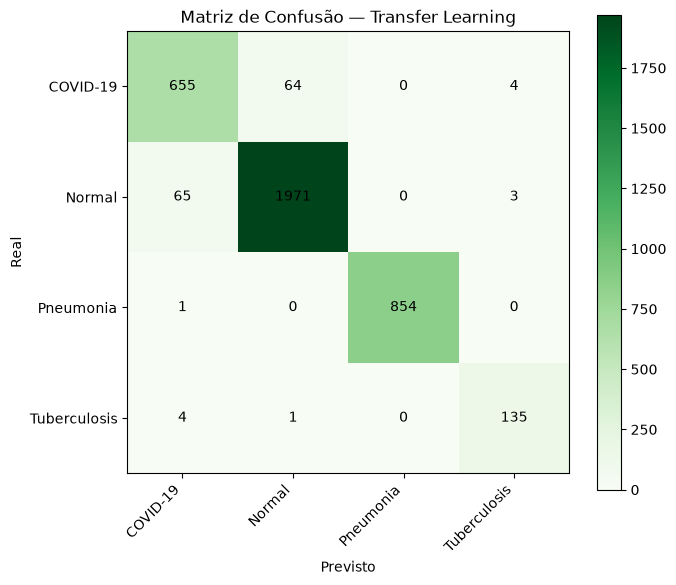

In [13]:
matriz = confusion_matrix(y_verdadeiro, y_previsto)

plt.figure(figsize=(7, 6))
plt.imshow(matriz, cmap="Greens")
plt.colorbar()
plt.xticks(range(4), nomes_classes, rotation=45, ha="right")
plt.yticks(range(4), nomes_classes)
plt.xlabel("Previsto"); plt.ylabel("Real")
plt.title("Matriz de Confusão — Transfer Learning")
for i in range(4):
    for j in range(4):
        plt.text(j, i, matriz[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

## 9. Teste amostral das 25 imagens por classe

Mesmo teste dos modelos anteriores (estilo Tabela 5 do artigo): sorteamos 25 imagens por classe e vemos quantas o modelo acerta. A `seed` fixa garante as mesmas imagens usadas nos outros modelos, para comparação justa.

In [14]:
import random

random.seed(42)
N_POR_CLASSE = 25

def preparar(caminho):
    img = tf.io.read_file(caminho)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (224, 224))
    img = preprocess_input(img)
    return tf.expand_dims(img, 0)

n = len(nomes_classes)
matriz25 = np.zeros((n, n), dtype=int)
for real, classe in enumerate(nomes_classes):
    arquivos = list((diretorio / classe).glob("*"))
    amostra = random.sample(arquivos, N_POR_CLASSE)
    for arq in amostra:
        previsto = int(np.argmax(melhor_modelo.predict(preparar(str(arq)), verbose=0)))
        matriz25[real][previsto] += 1

largura = max(len(c) for c in nomes_classes) + 2
print("Real".ljust(largura) + "".join(c.ljust(largura) for c in nomes_classes) + "Acertos")
for real in range(n):
    linha = nomes_classes[real].ljust(largura)
    linha += "".join(str(matriz25[real][j]).ljust(largura) for j in range(n))
    linha += f"{matriz25[real][real]}/{N_POR_CLASSE}"
    print(linha)

Real          COVID-19      Normal        Pneumonia     Tuberculosis  Acertos
COVID-19      22            3             0             0             22/25
Normal        4             21            0             0             21/25
Pneumonia     0             0             25            0             25/25
Tuberculosis  0             0             0             25            25/25


# Parte 2 — Fine-tuning (completando o transfer learning)

Na Parte 1 treinamos só a cabeça, com a base congelada (feature extraction). Agora **descongelamos o topo** da MobileNetV2 para que ela adapte suas características ao domínio de raio-X — atacando o *domain gap*.

Princípios:
- Descongelamos apenas as **camadas do topo** (as profundas, específicas do ImageNet); as rasas (bordas/texturas, universais) seguem congeladas.
- Camadas de **BatchNormalization** permanecem congeladas (boa prática).
- Taxa de aprendizado **minúscula (1e-5)**: ajuste fino que refina sem destruir o conhecimento pré-treinado.
- Continuamos a partir do modelo já treinado na Parte 1.

In [15]:
# Continua do modelo treinado na Parte 1 (robusto mesmo se reiniciou o kernel)
modelo = keras.models.load_model("melhor_modelo_transfer.keras")

# Localiza a base MobileNetV2 dentro do modelo
base = [c for c in modelo.layers if isinstance(c, keras.Model)][0]
print("Camadas na base:", len(base.layers))

# Descongela a base inteira...
base.trainable = True

# ...mas recongela as camadas iniciais (genéricas). Libera só o topo.
N_CONGELADAS = 100   # mantém congeladas as 100 primeiras camadas
for camada in base.layers[:N_CONGELADAS]:
    camada.trainable = False

# BatchNormalization sempre congelada (boa prática no fine-tuning)
for camada in base.layers:
    if isinstance(camada, keras.layers.BatchNormalization):
        camada.trainable = False

treinaveis = int(sum(np.prod(w.shape) for w in modelo.trainable_weights))
print("Parâmetros treináveis agora:", f"{treinaveis:,}")

Camadas na base: 154
Parâmetros treináveis agora: 1,844,740


In [16]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # passo minúsculo
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_ft = keras.callbacks.ModelCheckpoint(
    "melhor_modelo_finetuning.keras",
    monitor="val_accuracy", save_best_only=True, verbose=1
)

import time
inicio = time.time()
historico_ft = modelo.fit(
    dataset_treino,
    validation_data=dataset_teste,
    epochs=10,
    callbacks=[checkpoint_ft],
    class_weight=pesos_classes
)
print(f"\nTempo total: {(time.time()-inicio)/60:.1f} minutos")

Epoch 1/10


/home/gustavo/Documentos/GitHub/projetoInteligenciaArtificial/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.9500 - loss: 0.1060
Epoch 1: val_accuracy improved from None to 0.97365, saving model to melhor_modelo_finetuning.keras

Epoch 1: finished saving model to melhor_modelo_finetuning.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 428s 901ms/step - accuracy: 0.9500 - loss: 0.1060 - val_accuracy: 0.9736 - val_loss: 0.0774
Epoch 2/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.9681 - loss: 0.0700
Epoch 2: val_accuracy improved from 0.97365 to 0.97445, saving model to melhor_modelo_finetuning.keras

Epoch 2: finished saving model to melhor_modelo_finetuning.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 417s 887ms/step - accuracy: 0.9681 - loss: 0.0700 - val_accuracy: 0.9744 - val_loss: 0.0764
Epoch 3/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.9773 - loss: 0.0459
Epoch 3: val_accuracy improved from 0.97445 to 0.97631, saving model to melhor_modelo_finetuning.keras

Epoch 3: finished saving model to melhor_modelo_finetuning.keras
4

              precision    recall  f1-score   support

    COVID-19     0.9776    0.9668    0.9722       723
      Normal     0.9907    0.9922    0.9914      2039
   Pneumonia     0.9988    0.9988    0.9988       855
Tuberculosis     0.9586    0.9929    0.9754       140

    accuracy                         0.9888      3757
   macro avg     0.9814    0.9877    0.9845      3757
weighted avg     0.9888    0.9888    0.9888      3757



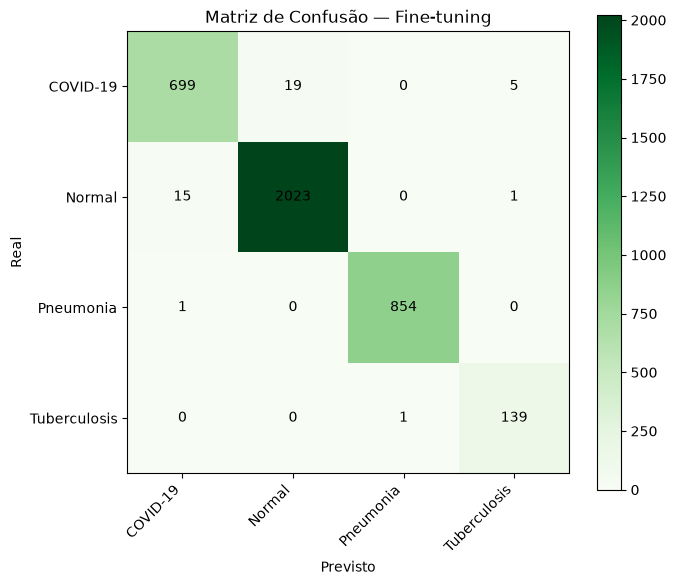

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

melhor_ft = keras.models.load_model("melhor_modelo_finetuning.keras")

y_verdadeiro, y_previsto = [], []
for imagens, rot in dataset_teste:
    previsoes = melhor_ft.predict(imagens, verbose=0)
    y_verdadeiro.extend(rot.numpy())
    y_previsto.extend(np.argmax(previsoes, axis=1))
y_verdadeiro = np.array(y_verdadeiro); y_previsto = np.array(y_previsto)

print(classification_report(y_verdadeiro, y_previsto, target_names=nomes_classes, digits=4))

matriz = confusion_matrix(y_verdadeiro, y_previsto)
plt.figure(figsize=(7, 6))
plt.imshow(matriz, cmap="Greens"); plt.colorbar()
plt.xticks(range(4), nomes_classes, rotation=45, ha="right")
plt.yticks(range(4), nomes_classes)
plt.xlabel("Previsto"); plt.ylabel("Real")
plt.title("Matriz de Confusão — Fine-tuning")
for i in range(4):
    for j in range(4):
        plt.text(j, i, matriz[i, j], ha="center", va="center")
plt.tight_layout(); plt.show()

In [18]:
import random

# Garante que o modelo do fine-tuning está carregado
melhor_ft = keras.models.load_model("melhor_modelo_finetuning.keras")

random.seed(42)              # mesmas imagens dos outros modelos
N_POR_CLASSE = 25

def preparar(caminho):
    img = tf.io.read_file(caminho)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (224, 224))
    img = preprocess_input(img)          # mesmo preprocessamento da MobileNet
    return tf.expand_dims(img, 0)

n = len(nomes_classes)
matriz25 = np.zeros((n, n), dtype=int)
for real, classe in enumerate(nomes_classes):
    arquivos = list((diretorio / classe).glob("*"))
    amostra = random.sample(arquivos, N_POR_CLASSE)
    for arq in amostra:
        previsto = int(np.argmax(melhor_ft.predict(preparar(str(arq)), verbose=0)))
        matriz25[real][previsto] += 1

largura = max(len(c) for c in nomes_classes) + 2
print("Real".ljust(largura) + "".join(c.ljust(largura) for c in nomes_classes) + "Acertos")
for real in range(n):
    linha = nomes_classes[real].ljust(largura)
    linha += "".join(str(matriz25[real][j]).ljust(largura) for j in range(n))
    linha += f"{matriz25[real][real]}/{N_POR_CLASSE}"
    print(linha)

Real          COVID-19      Normal        Pneumonia     Tuberculosis  Acertos
COVID-19      25            0             0             0             25/25
Normal        0             25            0             0             25/25
Pneumonia     0             0             25            0             25/25
Tuberculosis  0             0             0             25            25/25
